In [ ]:
import pandas as pd
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator,FormatStrFormatter,MaxNLocator
import matplotlib as mpl
import matplotlib.patches as mpatches
mpl.rcParams['font.family'] = 'Times New Roman'

all_data = []

files = "combined_csv/model_results_*.csv"


for file in files:
    df = pd.read_csv(file)

    match = re.search(r'alpha_(.*?)_temp_(.*?)_ratio_(.*?)_lr_(.*?).csv', file)

    if match:
        alpha = float(match.group(1))
        temp = float(match.group(2))
        prune = float(match.group(3))
        lr = float(match.group(4))
    else:
        print(f"Skipping file (no match): {file}")
        continue

    df["alpha"] = alpha
    df["temp"] = temp
    df["prune"] = prune
    df["lr"] = lr

    all_data.append(df)

print(all_data[0].head())          # first 5 rows
print(all_data[0].columns)         # column names
print(all_data[0].shape)

print("Total valid files:", len(all_data))  # DEBUG

df_all = pd.concat(all_data, ignore_index=True)

df_all = df_all[~df_all["model"].isin(remove_list)]
df_all = df_all.reset_index(drop=True)
print(df_all["model"].unique())

# df_all.to_csv("merged_results.csv", index=False)

In [ ]:
best_models = df_all.loc[df_all.groupby("model")["accuracy"].idxmax()]

print(best_models[["model", "accuracy", "params", "size_mb", "flops"]])


print(best_models[["model", "accuracy", "precision", "recall", "f1"]])

df["model"] = df_all["model"].str.strip()

# best_models = (
#     df.sort_values("accuracy", ascending=False)
#       .groupby("model", as_index=False)
#       .first()
# )

print(best_models[["model", "accuracy", "precision", "recall", "f1"]])


best_models.to_csv(f"metrics.csv")
metrics = ["accuracy", "precision", "recall", "f1"]

plot_df = best_models.set_index("model")[metrics]

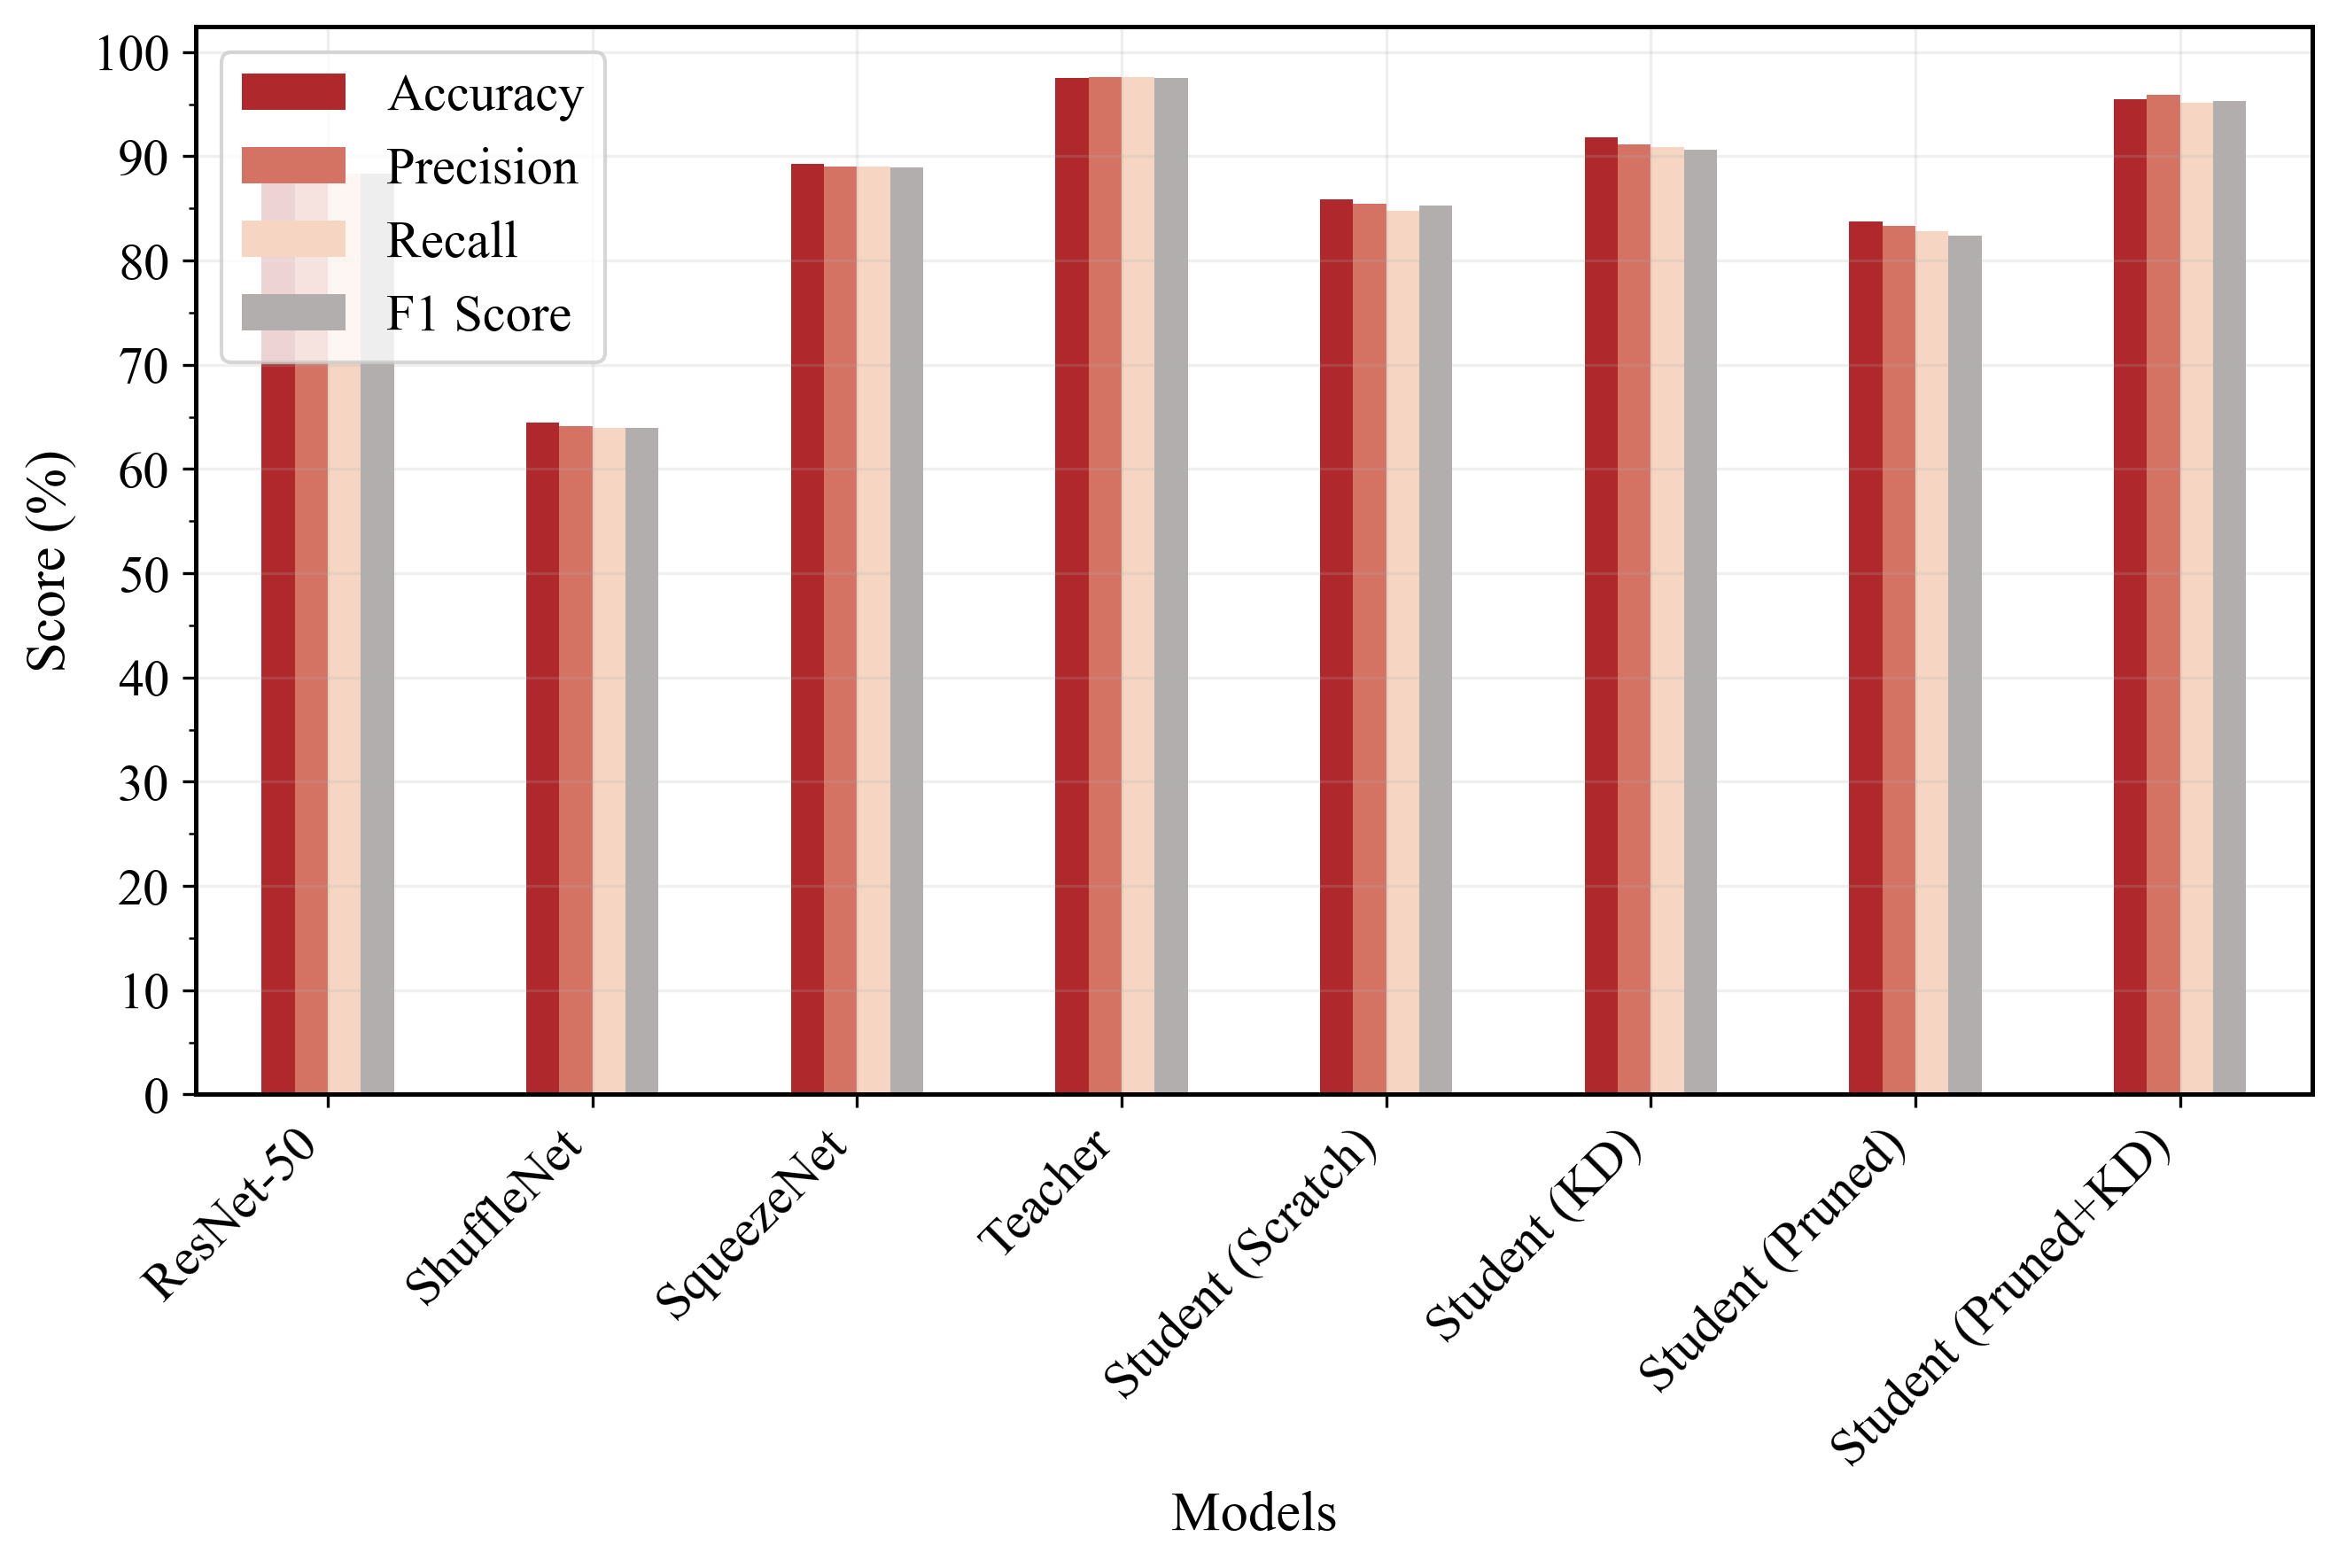

In [3]:

model_name_map_1 = {
    # "mobilenetv3_small": "MobileNetV3-S",
    "resnet50": "ResNet-50",
    "shufflenet": "ShuffleNet",
    "squeezenet": "SqueezeNet",
    "student_kd": "Student (KD)",
    "student_pruned": "Student (Pruned)",
    "student_pruned_kd": "Student (Pruned+KD)",
    "student_scratch": "Student (Scratch)",
    "teacher": "Teacher"
}

metric_name_map_1 = {
    "accuracy": "Accuracy",
    "f1": "F1 Score",
    "precision": "Precision",
    "recall": "Recall"
    # adjust to match your actual column names
}

model_order_1 = [
    # "mobilenetv3_small",
    "resnet50",
    "shufflenet",
    "squeezenet",
    "teacher",
    "student_scratch",
    "student_kd",
    "student_pruned",
    "student_pruned_kd",
]

best_models=pd.read_csv("metrics.csv")

plot_df_1 = best_models.set_index("model")[["accuracy","precision","recall","f1"]]
# plot_df_renamed = plot_df.rename(index=model_name_map, columns=metric_name_map)
plot_df_renamed_1 = (
    plot_df_1
    .reindex(model_order_1)               # reorder rows
    .rename(index=model_name_map_1, columns=metric_name_map_1)
)
# colors = ['#0000A2', '#E9C716', '#BC272D', '#50AD9F']
colors = ["#ae282c", "#d47264", "#f6d6c2", "#b2aeae"] #red shed
# colors = ["#E76649", "#C92020", "#7A83E7", "#05108D"]

fig, ax = plt.subplots(figsize=(8.9, 6.0), dpi=300)

plot_df_renamed_1.plot(kind="bar", ax=ax, color = colors)  

# ax = plot_df.plot(kind="bar")

# Labels
ax.set_xlabel("Models", fontsize=15,  )
ax.set_ylabel("Score (%)", fontsize=15,  )

# X tick labels rotation (separate from xlabel)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Legend
ax.legend(fontsize=14)

# Grid
ax.grid(True, alpha=0.2)

# Y-axis tick spacing
ax.yaxis.set_major_locator(MultipleLocator(10))
ax.yaxis.set_minor_locator(MultipleLocator(5))

# Spines
for spine in ax.spines.values():
    spine.set_linewidth(1.2)
    spine.set_edgecolor('black')

# Tick label styling
ax.tick_params(axis='both', labelsize=15)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    # label.set_fontname('Arial')
    # label.set_fontweight('bold')
    label.set_fontsize(14)

plt.tight_layout()
# plt.savefig("best_models_performance.pdf", dpi=400)
plt.show()
plt.close()

In [ ]:
model_name_map_xx = {
    # "mobilenetv3_small": "MobileNetV3-S",
    "resnet50": "ResNet-50",
    "shufflenet": "ShuffleNet",
    "squeezenet": "SqueezeNet",
    "student_kd": "Student (KD)",
    "student_pruned": "Student (Pruned)",
    "student_pruned_kd": "Student (Pruned+KD)",
    "student_scratch": "Student (Scratch)",
    "teacher": "Teacher"
}

plot_df_xx = best_models.set_index("model")[["accuracy","precision","recall","f1"]]

metric_name_map_xx = {
    "accuracy": "Accuracy",
    "precision": "Precision",
    'size_mb': 'Model size',
    # "recall": "Recall",
    "f1": "F1 Score"
    # 'params': 'Parameters'
}

model_order_xx = [
    # "mobilenetv3_small",
    "resnet50",
    "shufflenet",
    "squeezenet",
    "teacher",
    "student_scratch",
    "student_kd",
    "student_pruned",
    "student_pruned_kd",
]


plot_df_renamed_xx = (
    plot_df_xx
    .reindex(model_order_xx)               # reorder rows
    .rename(index=model_name_map_xx, columns=metric_name_map_xx)
)

# df_norm = plot_df_renamed_xx.div(plot_df_renamed_xx.max(axis=0)) * 100

metrics = ['Accuracy', 'Precision', 'Recall', 'F-1']  # adjust to your actual columns
N = len(metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True), dpi=300)

colors2 = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
          '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

for i, (idx, row) in enumerate(plot_df_renamed_xx.iterrows()):
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, color=colors2[i % len(colors2)], linewidth=2, label=idx)
    ax.fill(angles, values, color=colors2[i % len(colors2)], alpha=0.08)

# --- Remove circular gridlines, keep spoke lines ---
ax.yaxis.set_visible(False)          # hide circular rings
ax.grid(False)                        # remove all grid
ax.spines['polar'].set_visible(False) # remove outer circle

# --- Draw spoke lines manually ---
for angle in angles[:-1]:
    ax.plot([angle, angle],
            [0, ax.get_ylim()[1]],
            color='grey', linewidth=0.7, linestyle='--', alpha=0.2)

# --- Tick values on vertical (top) axis only ---
top_angle = angles[0]  # first metric is at the top spoke
y_min = 0
y_max = 100  # adjust to your data range
tick_vals = np.arange(20, y_max + 1, 20)  # adjust step as needed

for val in tick_vals:
    ax.text(top_angle, val, str(int(val)),
            ha='center', va='bottom',
            fontsize=9, color='gray')

# --- Labels and legend ---
ax.set_thetagrids(np.degrees(angles[:-1]), metrics, fontsize=14)
ax.set_ylim(0, 105)

# ax.legend(loc='upper right', bbox_to_anchor=(0.5, -0.08),  ncol=4,
#           fontsize=6, frameon=True)
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.08),   # negative y pushes it below the plot
    ncol=4,                         # adjust to number of models per row
    fontsize=11,
    frameon=False
)

plt.tight_layout()
plt.savefig('model_metrics.pdf', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
# import numpy as np
fig, ax1 = plt.subplots(figsize=(5.9, 4.9), dpi=600)
metric_name_map_3 = {
    "accuracy": "Accuracy",
    "size_mb": "Model size (MB)"
}

model_order_3 = [
    # "mobilenetv3_small",
    "resnet50",
    "shufflenet",
    "squeezenet",
    "teacher",
    "student_scratch",
    "student_kd",
    "student_pruned",
    "student_pruned_kd",
]

model_name_map_3 = {
    # "mobilenetv3_small": "MobileNetV3-S",
    "resnet50": "ResNet-50",
    "shufflenet": "ShuffleNet",
    "squeezenet": "SqueezeNet",
    "student_kd": "Student (KD)",
    "student_pruned": "Student (Pruned)",
    "student_pruned_kd": "Student (Pruned+KD)",
    "student_scratch": "Student (Scratch)",
    "teacher": "Teacher"
}

ax2 = ax1.twinx()


width = 0.35
plot_df_3 = best_models.set_index("model")[["accuracy","size_mb"]]

plot_df_renamed_3 = (
    plot_df_3
    .reindex(model_order_3)               # reorder rows
    .rename(index=model_name_map_3, columns=metric_name_map_3)
)
x = np.arange(len(plot_df_renamed_3))


# color_size = "#DF6B51"       
# color_acc  = "#7A83E7"  
color_size = colors[0]       
color_acc  = colors[1] 

bars1 = ax1.bar(x - width/2, plot_df_renamed_3["Model size (MB)"], width, label="Model size (MB)", color=color_size)

# Right axis — Accuracy
bars2 = ax2.bar(x + width/2, plot_df_renamed_3["Accuracy"], width, label="Accuracy", color=color_acc)

# X ticks
ax1.set_xticks(x)
ax1.set_xticklabels(plot_df_renamed_3.index, rotation=45, ha='right')

ax1.set_ylabel("Model Size (MB)", fontsize=15, fontweight='bold', color=color_size)
ax1.tick_params(axis='y', labelcolor=color_size, labelsize=13)
ax1.spines['left'].set_edgecolor(color_size)
ax1.spines['left'].set_linewidth(1.2)

# Right axis (Accuracy) — color_acc
ax2.set_ylabel("Accuracy (%)", fontsize=15, fontweight='bold', color=color_acc)
ax2.tick_params(axis='y', labelcolor=color_acc, labelsize=13)
ax2.spines['right'].set_edgecolor(color_acc)
ax2.spines['right'].set_linewidth(1.2)


# Combined legend
lines = [bars1, bars2]
labels = [b.get_label() for b in lines]
ax1.legend(lines, labels, fontsize=11, framealpha=0.3, loc='upper left')

# Grid
ax1.grid(True, alpha=0.2)

# Spines
for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
        spine.set_edgecolor('black')
    ax.tick_params(axis='both', labelsize=13)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        # label.set_fontweight('bold')
        label.set_fontsize(13)

plt.tight_layout()
plt.savefig("model_accuracy_size.pdf", dpi=600,  bbox_inches='tight')
plt.show()